# Neural Network — Coffee Roasting Classification
Binary classification using a two-layer neural network in Keras/TensorFlow.
Predicts good vs bad roast based on temperature and duration.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Input
from lab_coffee_utils import load_coffee_data, plt_roast, plt_prob, plt_layer, plt_network, plt_output_unit
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

## Load and Inspect Data
X contains temperature and duration features. Y contains binary labels (1=good roast).

In [4]:
X,Y = load_coffee_data()
print(X.shape,Y.shape)

(200, 2) (200, 1)


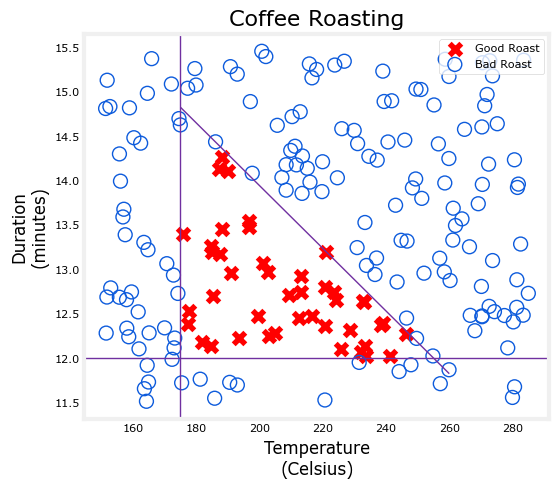

In [5]:
plt_roast(X,Y)

## Normalization
tf.keras Normalization layer computes mean and variance from training data.
Same layer reused at prediction time — equivalent to storing mu and sigma manually.

In [6]:
print(f"Temperature before normalisation:{np.ptp(X[:,0]):.2f}")
print(f"Duration before normalisation:{np.ptp(X[:,1]):.2f}")
norm_l = tf.keras.layers.Normalization(axis=-1)
norm_l.adapt(X)
Xn = norm_l(X)
print(f"Temperature after normalisation:{np.ptp(Xn[:,0]):.2f}")
print(f"Duration after normalisation:{np.ptp(Xn[:,1]):.2f}")


Temperature before normalisation:133.67
Duration before normalisation:3.94
Temperature after normalisation:3.34
Duration after normalisation:3.49


## Dataset Augmentation
Small dataset tiled 1000x to give Adam optimizer sufficient gradient updates per epoch.
Not real augmentation — purely to increase training steps on limited data.
Shuffled after tiling to prevent ordered repetition.

In [7]:
Xt = np.tile(Xn,(1000,1))
Yt = np.tile(Y,(1000,1))

rng = np.random.default_rng(42)
indices = np.arange(len(Xt))
rng.shuffle(indices)

Xt = Xt[indices]
Yt = Yt[indices]

print(Xt.shape, Yt.shape)

(200000, 2) (200000, 1)


## Model Architecture
Two layer network: 3 sigmoid units in layer 1, 1 sigmoid unit in layer 2.
Layer 1 learns intermediate features, layer 2 combines them into a final probability.

In [8]:
tf.random.set_seed(1234)
model = Sequential(
    [
        Input(shape=(2,)),
        Dense(3, activation='sigmoid', name='layer1'),
        Dense(1, activation='sigmoid', name='layer2')
    ]
)

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
)

model.fit(
    Xt, Yt,
    epochs=10,
    shuffle=True
)

Epoch 1/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 3s 454us/step - loss: 0.1982
Epoch 2/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 3s 472us/step - loss: 0.1147
Epoch 3/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 3s 453us/step - loss: 0.0456
Epoch 4/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 3s 469us/step - loss: 0.0160
Epoch 5/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 3s 448us/step - loss: 0.0105
Epoch 6/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 3s 447us/step - loss: 0.0074
Epoch 7/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 3s 463us/step - loss: 0.0053
Epoch 8/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 3s 437us/step - loss: 0.0038
Epoch 9/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 3s 468us/step - loss: 0.0028
Epoch 10/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 3s 469us/step - loss: 0.0020


## Inspect Learned Weights
Extracting W and b from each layer to inspect what the network learned.

In [11]:
W1, b1 = model.get_layer('layer1').get_weights()
W2, b2 = model.get_layer('layer2').get_weights()
print('W1:\n',W1,'\nb1:',b1)
print('\nW2:\n',W2,'\nb2:',b2)

W1:
 [[ -0.08  14.7  -10.87]
 [ -9.08  12.23  -0.22]] 
b1: [-11.25   1.82 -11.86]

W2:
 [[-45.53]
 [-41.61]
 [-49.52]] 
b2: [26.]


## Override with Pre-tuned Weights
Replacing trained weights with Ng's reference weights for consistent visualization.
These weights produce clean, interpretable decision boundaries for the plots below.

In [12]:
W1 = np.array([
    [-8.94,  0.29, 12.89],
    [-0.17, -7.34, 10.79]] )
b1 = np.array([-9.87, -9.28,  1.01])
W2 = np.array([
    [-31.38],
    [-27.86],
    [-32.79]])
b2 = np.array([15.54])

## Prediction on New Data
Two test points: one expected bad roast, one expected good roast.
Normalized using the same norm_l layer fitted on training data.

In [13]:
X_test = np.array([
    [200,13.9],
    [200,17]
])
X_testn = norm_l(X_test)
prediction = model.predict(X_testn)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
[[9.92e-01]
 [1.62e-07]]


## Decision
Threshold sigmoid output at 0.5 to get binary classification decision.

In [14]:
yhat = (prediction>=0.5).astype(int)
print(f"Decisions=\n",yhat)

Decisions=
 [[1]
 [0]]


## Understanding the Layer 1 Visualization

### What the Plot Shows
Each of the three subplots corresponds to one neuron in layer 1.
Every neuron takes the same two inputs — Temperature and Duration —
but has learned a different set of weights W and bias b.
The plot runs each neuron independently across the entire feature space
and visualizes its output probability as a color map.

### The Blue Shaded Region
The blue shaded area is where that neuron outputs P(y=1) > 0.5 — the region
where the neuron is "firing." Outside the shaded region the neuron outputs
below 0.5 — not firing.

Color intensity represents confidence:
- Dark blue → probability close to 1.0, neuron is highly activated
- Light blue → probability just above 0.5, neuron is weakly activated
- White/unshaded → probability below 0.5, neuron is not firing

The diagonal line is the decision boundary — the exact line where
the neuron outputs exactly 0.5. It is defined by:
    W[0]*Temperature + W[1]*Duration + b = 0
Everything on one side fires, everything on the other does not.

## Important — High Activation Means Bad Roast

In this network, each layer 1 neuron firing strongly is a bad roast signal.
The blue shaded region (high P) corresponds to bad roast conditions.
This is visible in the plot — blue circles (bad roast) cluster inside
the shaded regions, red crosses (good roast) fall outside.

The output layer weights W2 are all large and negative (-31, -27, -32).
When layer 1 neurons fire strongly, the output neuron receives a large
negative value, sigmoid maps it toward 0 — predicted bad roast.
The good roast prediction only emerges where all three neurons are
weakly activated simultaneously — the small triangular unshaded region
where none of the bad roast conditions are triggered.

### Reading Each Unit

**Unit 0**
Boundary is nearly vertical. This neuron is almost entirely
sensitive to Temperature and barely responds to Duration.
It fires in the left strip — low temperature regardless of duration.
It has learned: "temperature too low."

**Unit 1**
Boundary is nearly horizontal. This neuron is almost entirely
sensitive to Duration and barely responds to Temperature.
It fires in the bottom strip — short duration regardless of temperature.
It has learned: "roast time too short."

**Unit 2**
Boundary cuts diagonally. This neuron fires in the lower-right
triangular region — high temperature combined with low duration.
It has learned a joint condition across both features simultaneously.
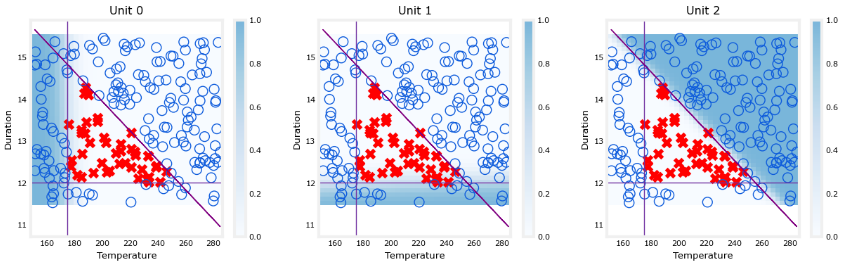

### How the Output Layer Uses These
The output layer (layer 2) receives three numbers — one from each unit —
and learns a weighted combination of them. The triangular good-roast region
visible in plt_network is where all three units produce a combination
that the output neuron has learned to map to P(good roast) > 0.5.
No single unit could produce that triangular boundary alone.
It is an emergent shape from three linear boundaries intersecting.

### Why Each Neuron Learned a Different Job — Symmetry Breaking

If all three neurons had been initialized with identical weights,
they would compute identical outputs on every input. The gradients
flowing back through each neuron during backpropagation would also
be identical. Every update would be identical. After any number of
epochs, all three neurons would still be clones of each other —
the network would behave as if it had a single neuron in layer 1
regardless of how many were defined.

This is called the symmetry problem.

Random initialization breaks this symmetry. Each neuron starts with
slightly different W and b values drawn from a random distribution.
On the very first forward pass they produce slightly different outputs.
On the very first backward pass they receive slightly different gradients.
This causes them to take slightly different update steps. Once they
diverge even slightly, the error signal flowing back through each neuron
is different on the next iteration — so they keep diverging. Over many
epochs this small initial difference compounds into completely distinct
roles as each neuron specializes toward the part of the error it is
most sensitive to.

Random initialization is not a technical detail — it is what makes
depth in a neural network meaningful. Without it, a 3-neuron layer
is no more expressive than a 1-neuron layer.

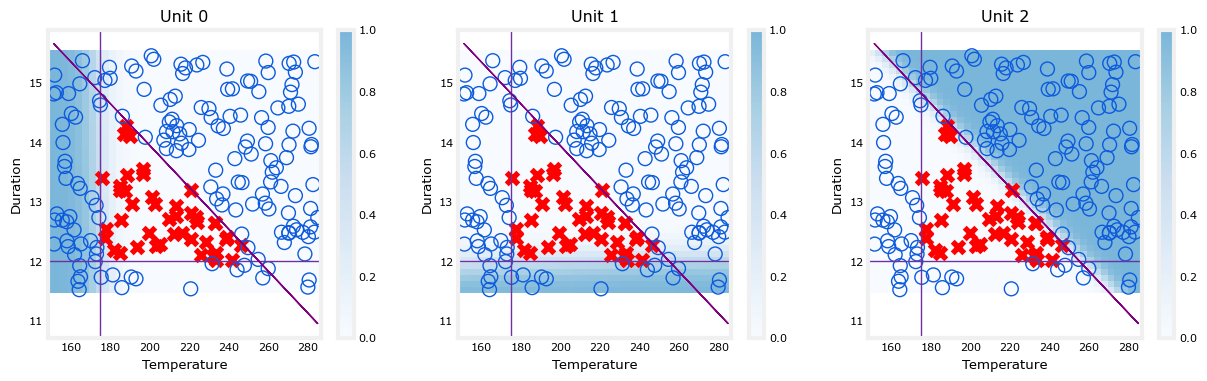

In [16]:
plt_layer(X, Y.reshape(-1,), W1, b1, norm_l)

## Network Decision Boundary
Combined output of both layers. The triangular good-roast region emerges from
the intersection of the three boundaries learned by layer 1.

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


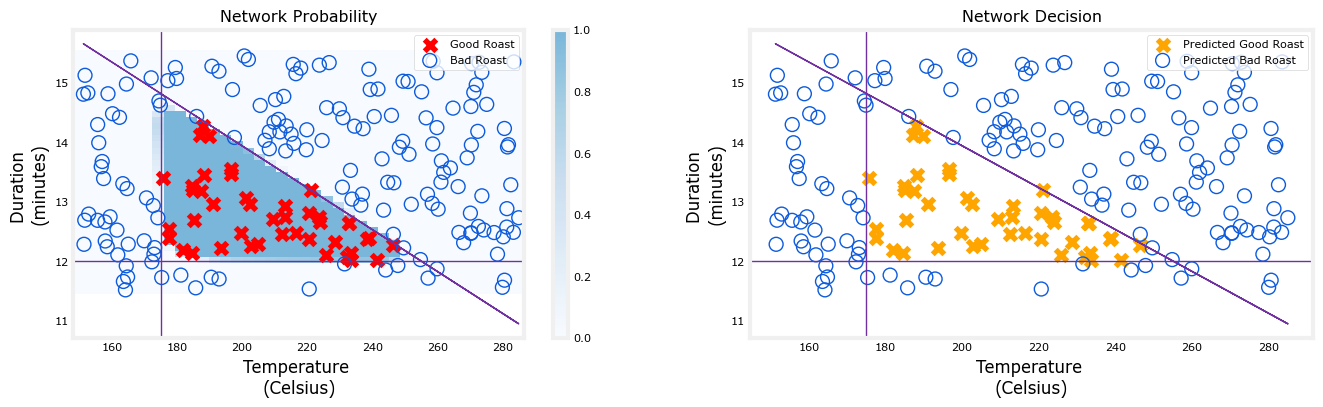

In [17]:
netf= lambda x : model.predict(norm_l(x))
plt_network(X,Y,netf)